In [125]:
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.anova import AnovaRM
import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.formula.api import logit


from scipy.stats import norm

In [126]:
files = [
    "table1.csv",
    "table2.csv",
    "table3.csv",
    "table4.csv"
]

dfs = []

for file in files:
    temp = pd.read_csv(file)
    temp["source_file"] = file
    dfs.append(temp)

df = pd.concat(dfs, ignore_index=True)

In [127]:
len(df['participant_id'].unique())

47

In [128]:
df = df[df['participant_id'].str.contains('p_1781091046584_u3xg|p_1781059401023_5th1') == False]

In [129]:
len(df['participant_id'].unique())

45

---

In [130]:
face_df = df[df['block'] == 'face_face']

In [131]:
face_df.device.value_counts()

device
desktop    1720
phone        80
Name: count, dtype: int64

In [132]:
face_df = face_df[['participant_id','device', 'set_size', 'screen_width', 'age','gender', 'ai_use_frequency', 'ai_detection_experience', 'target_origin', 'target_present', 'cue_image','is_practice', 'no_response', 'rt','correct', 'trial_index_global']]
face_df

,participant_id,device,set_size,screen_width,age,gender,ai_use_frequency,ai_detection_experience,target_origin,target_present,cue_image,is_practice,no_response,rt,correct,trial_index_global
416,p_1781092550069_p454,desktop,4.0,1920,21,female,3,3,real,True,real_015.png,True,False,2373.0,True,9.0
422,p_1781092550069_p454,desktop,8.0,1920,21,female,3,3,real,False,real_015.png,True,False,1650.0,True,15.0
428,p_1781092550069_p454,desktop,4.0,1920,21,female,3,3,real,False,real_020.png,True,False,1118.0,True,21.0
434,p_1781092550069_p454,desktop,8.0,1920,21,female,3,3,ai,False,ai_004.png,True,False,2141.0,True,27.0
440,p_1781092550069_p454,desktop,4.0,1920,21,female,3,3,real,True,real_033.png,True,False,844.0,True,33.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11920,p_1781108603474_wyud,desktop,4.0,1440,18,female,4,3,ai,False,ai_001.png,False,False,1223.0,True,193.0
11925,p_1781108603474_wyud,desktop,4.0,1440,18,female,4,3,ai,False,ai_007.png,False,False,1622.0,True,198.0
11930,p_1781108603474_wyud,desktop,4.0,1440,18,female,4,3,real,False,real_020.png,False,False,966.0,True,203.0
11935,p_1781108603474_wyud,desktop,8.0,1440,18,female,4,3,real,False,real_010.png,False,False,3921.0,True,208.0


In [133]:
face_df = face_df[face_df['is_practice'] == False]
face_df

,participant_id,device,set_size,screen_width,age,gender,ai_use_frequency,ai_detection_experience,target_origin,target_present,cue_image,is_practice,no_response,rt,correct,trial_index_global
465,p_1781092550069_p454,desktop,8.0,1920,21,female,3,3,ai,True,ai_001.png,False,False,2854.0,False,58.0
470,p_1781092550069_p454,desktop,4.0,1920,21,female,3,3,real,True,real_039.png,False,False,1033.0,True,63.0
475,p_1781092550069_p454,desktop,8.0,1920,21,female,3,3,real,True,real_002.png,False,False,1353.0,True,68.0
480,p_1781092550069_p454,desktop,4.0,1920,21,female,3,3,ai,False,ai_002.png,False,False,1292.0,True,73.0
485,p_1781092550069_p454,desktop,8.0,1920,21,female,3,3,real,True,real_003.png,False,False,1157.0,True,78.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11920,p_1781108603474_wyud,desktop,4.0,1440,18,female,4,3,ai,False,ai_001.png,False,False,1223.0,True,193.0
11925,p_1781108603474_wyud,desktop,4.0,1440,18,female,4,3,ai,False,ai_007.png,False,False,1622.0,True,198.0
11930,p_1781108603474_wyud,desktop,4.0,1440,18,female,4,3,real,False,real_020.png,False,False,966.0,True,203.0
11935,p_1781108603474_wyud,desktop,8.0,1440,18,female,4,3,real,False,real_010.png,False,False,3921.0,True,208.0


In [134]:
faces_types = {"ai_001.png": ("female","white"),
    "ai_002.png":  ("male", "white"),
    "ai_003.png":   ("female", "asian"),
    "ai_004.png":   ("male", "white"),
    "ai_005.png":   ("female", "white"),
    "ai_006.png":   ("male", "black"),
    "ai_007.png":   ("female", "asian"),
    "ai_008.png":   ("male", "asian"),
    "real_002.png": ("female", "asian"),
    "real_003.png": ("female", "asian"),
    "real_007.png": ("male", "asian"),
    "real_010.png": ("male", "asian"),
    "real_015.png": ("female", "black"),
    "real_020.png": ("male", "black"),
    "real_033.png": ("male", "white"),
    "real_039.png": ("female", "white"),
    }

face_df = face_df.copy()
face_df['pic_gender'] = face_df['cue_image'].apply(lambda x: faces_types[x][0])
face_df['pic_race'] = face_df['cue_image'].apply(lambda x: faces_types[x][1])


---

In [135]:
pivot1 = face_df.groupby(['participant_id', 'target_origin'])[['correct']].mean().unstack()
pivot1

correct          
target_origin               ai      real
participant_id                          
p_1781092501070_slnb    0.9375    0.9375
p_1781092550069_p454  0.823529       1.0
p_1781092616290_69bk  0.944444       1.0
p_1781092650092_42ud       0.0       0.0
p_1781092658017_k0gj       1.0       1.0
p_1781092679909_6iym       1.0    0.9375
p_1781092702742_7pkp       1.0       1.0
p_1781092768274_uxsj  0.823529       1.0
p_1781092768697_v4ky  0.692308  0.947368
p_1781092804785_ttvx       1.0       1.0
p_1781092829779_yepq  0.823529       1.0
p_1781092881484_9drg  0.111111       0.0
p_1781092947156_bp9x    0.8125    0.9375
p_1781092969592_8clp    0.8125    0.9375
p_1781092990479_fox1       1.0       1.0
p_1781093045234_bbus       1.0       1.0
p_1781093073592_tzox    0.9375    0.9375
p_1781093076609_d8wr       1.0       1.0
p_1781093088350_fp4u       1.0       1.0
p_1781093158793_02gt       1.0       1.0
p_1781093180745_3pfs  0.928571  0.888889
p_1781093229709_2mnu       1.0       1.0
p_1781093275387_j190  0.769231  0.947368
p_1781093451772_jtrm       1.0  0.941176
p_1781093875756_0nqn  0.882353  0.933333
p_1781094612340_qsqj       1.0    0.9375
p_1781094618236_0ug9  0.941176  0.933333
p_1781094847388_ibfk  0.588235  0.933333
p_1781095442408_vlly  0.888889  0.928571
p_1781095506579_9hhb     0.875    0.9375
p_1781095527704_c2kx       1.0     0.875
p_1781095623962_1i62  0.933333  0.941176
p_1781096248308_627m  0.933333       1.0
p_1781096465926_0odu    0.8125       1.0
p_1781096733992_dh0r       1.0       1.0
p_1781097135164_4k5k       1.0       1.0
p_1781097539278_xhk6       1.0       1.0
p_1781097609226_l1ec  0.933333  0.882353
p_1781098866704_q749  0.944444  0.857143
p_1781100154429_ewom       1.0       1.0
p_1781102075226_loiu  0.866667  0.941176
p_1781105529578_l2ki  0.888889  0.714286
p_1781107502737_c3ui  0.866667  0.823529
p_1781108603474_wyud       1.0       1.0
p_1781112847190_eioa  0.928571  0.944444

**Дополнительное исключение участников по качеству ответов.**

Двое участников показали точность 0 в одной из категорий `target_origin` (см. таблицу выше). Проверка по переменной `no_response` показывает, что у этих участников доля проб без ответа (timeout) составила 100% и 93.75% соответственно — то есть участники фактически не отвечали почти на всём эксперименте (вероятно, техническая проблема с привязкой клавиш или невыполнение инструкции на их устройстве). Согласно правилам обработки данных, пропуск ответа кодируется как неверный ответ, поэтому такие протоколы дают accuracy ≈ 0 не из-за систематических ошибок различения, а из-за отсутствия валидных ответов. Эти два участника исключаются из дальнейшего анализа как невалидные протоколы (контроль качества данных, а не статистический выбор, влияющий на проверку гипотез).

In [136]:
accuracy0 = pivot1[(pivot1['correct']['ai'] == 0) | (pivot1['correct']['real'] == 0)].index
face_df = face_df[face_df['participant_id'].str.contains('|'.join(accuracy0)) == False].copy()
face_df


,participant_id,device,set_size,screen_width,age,gender,ai_use_frequency,ai_detection_experience,target_origin,target_present,cue_image,is_practice,no_response,rt,correct,trial_index_global,pic_gender,pic_race
465,p_1781092550069_p454,desktop,8.0,1920,21,female,3,3,ai,True,ai_001.png,False,False,2854.0,False,58.0,female,white
470,p_1781092550069_p454,desktop,4.0,1920,21,female,3,3,real,True,real_039.png,False,False,1033.0,True,63.0,female,white
475,p_1781092550069_p454,desktop,8.0,1920,21,female,3,3,real,True,real_002.png,False,False,1353.0,True,68.0,female,asian
480,p_1781092550069_p454,desktop,4.0,1920,21,female,3,3,ai,False,ai_002.png,False,False,1292.0,True,73.0,male,white
485,p_1781092550069_p454,desktop,8.0,1920,21,female,3,3,real,True,real_003.png,False,False,1157.0,True,78.0,female,asian
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11920,p_1781108603474_wyud,desktop,4.0,1440,18,female,4,3,ai,False,ai_001.png,False,False,1223.0,True,193.0,female,white
11925,p_1781108603474_wyud,desktop,4.0,1440,18,female,4,3,ai,False,ai_007.png,False,False,1622.0,True,198.0,female,asian
11930,p_1781108603474_wyud,desktop,4.0,1440,18,female,4,3,real,False,real_020.png,False,False,966.0,True,203.0,male,black
11935,p_1781108603474_wyud,desktop,8.0,1440,18,female,4,3,real,False,real_010.png,False,False,3921.0,True,208.0,male,asian


In [137]:
face_df[face_df['no_response'] == True][['correct']]

,correct
6131,False
11359,False
11364,False
11369,False
11374,False


---

In [138]:
face_df.groupby('target_origin')[['correct']].value_counts(normalize = True)

target_origin  correct
ai             True       0.921512
               False      0.078488
real           True       0.953488
               False      0.046512
Name: proportion, dtype: float64

**Примечание:** приведённый ниже хи-квадрат тест ассоциации `target_origin` × `correct` — наивная предварительная проверка без учёта повторных измерений (каждый участник вносит несколько наблюдений). Используется только как ориентир перед основным анализом; в финальные результаты не включается, так как корректная проверка гипотезы выполняется ниже через модели с кластеризованными по участнику стандартными ошибками.

In [139]:
crosstab1 = pd.crosstab(df['target_origin'], df['correct'])
table1 = sm.stats.Table.from_data(df[['target_origin','correct']])

In [140]:
print(table1.test_nominal_association())
table1.resid_pearson

df          1
pvalue      0.08846826135102748
statistic   2.902026621897109


correct,False,True
target_origin,,
ai,1.140647,-0.387218
real,-1.140647,0.387218


In [141]:
face_df['correct_numeric'] = face_df['correct'].apply(lambda x: 1 if x == True else 0)
face_df['tp'] = face_df['target_present'].apply(lambda x: True if x == True or x == 'True' else False)
face_df

,participant_id,device,set_size,screen_width,age,gender,ai_use_frequency,ai_detection_experience,target_origin,target_present,cue_image,is_practice,no_response,rt,correct,trial_index_global,pic_gender,pic_race,correct_numeric,tp
465,p_1781092550069_p454,desktop,8.0,1920,21,female,3,3,ai,True,ai_001.png,False,False,2854.0,False,58.0,female,white,0,True
470,p_1781092550069_p454,desktop,4.0,1920,21,female,3,3,real,True,real_039.png,False,False,1033.0,True,63.0,female,white,1,True
475,p_1781092550069_p454,desktop,8.0,1920,21,female,3,3,real,True,real_002.png,False,False,1353.0,True,68.0,female,asian,1,True
480,p_1781092550069_p454,desktop,4.0,1920,21,female,3,3,ai,False,ai_002.png,False,False,1292.0,True,73.0,male,white,1,False
485,p_1781092550069_p454,desktop,8.0,1920,21,female,3,3,real,True,real_003.png,False,False,1157.0,True,78.0,female,asian,1,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11920,p_1781108603474_wyud,desktop,4.0,1440,18,female,4,3,ai,False,ai_001.png,False,False,1223.0,True,193.0,female,white,1,False
11925,p_1781108603474_wyud,desktop,4.0,1440,18,female,4,3,ai,False,ai_007.png,False,False,1622.0,True,198.0,female,asian,1,False
11930,p_1781108603474_wyud,desktop,4.0,1440,18,female,4,3,real,False,real_020.png,False,False,966.0,True,203.0,male,black,1,False
11935,p_1781108603474_wyud,desktop,8.0,1440,18,female,4,3,real,False,real_010.png,False,False,3921.0,True,208.0,male,asian,1,False


In [142]:
face_df.groupby('target_origin')[['age','ai_use_frequency','ai_detection_experience']].mean()

,age,ai_use_frequency,ai_detection_experience
target_origin,,,
ai,19.632267,3.582849,3.409884
real,19.670058,3.626453,3.427326


In [143]:
face_df.groupby('target_origin')['gender'].value_counts(normalize= True).to_frame()

proportion
target_origin gender            
ai            female    0.578488
              male      0.421512
real          female    0.584302
              male      0.415698

In [144]:
model1 = logit("correct_numeric ~ C(target_origin, Treatment(reference='real'))", data = face_df).fit(cov_type='cluster', cov_kwds={'groups': face_df['participant_id']})
model1.summary()

Optimization terminated successfully.
         Current function value: 0.231587
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:        correct_numeric   No. Observations:                 1376
Model:                          Logit   Df Residuals:                     1374
Method:                           MLE   Df Model:                            1
Date:                Sun, 14 Jun 2026   Pseudo R-squ.:                0.009428
Time:                        06:03:12   Log-Likelihood:                -318.66
converged:                       True   LL-Null:                       -321.70
Covariance Type:              cluster   LLR p-value:                   0.01378
=======================================================================================================================
                                                          coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------------
Intercept                                               3.0204      0.194     15.589      0.000       2.641       3.400
C(target_origin, Treatment(reference='real'))[T.ai]    -0.5574      0.244     -2.281      0.023      -1.036      -0.078
=======================================================================================================================
"""

In [145]:
model2 = logit("correct_numeric ~ C(target_origin, Treatment(reference='real')) + gender + age + ai_use_frequency + ai_detection_experience + C(set_size) + pic_gender + pic_race", data = face_df).fit(cov_type='cluster', cov_kwds={'groups': face_df['participant_id']})
model2.summary()

Optimization terminated successfully.
         Current function value: 0.216611
         Iterations 8


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:        correct_numeric   No. Observations:                 1376
Model:                          Logit   Df Residuals:                     1366
Method:                           MLE   Df Model:                            9
Date:                Sun, 14 Jun 2026   Pseudo R-squ.:                 0.07349
Time:                        06:03:12   Log-Likelihood:                -298.06
converged:                       True   LL-Null:                       -321.70
Covariance Type:              cluster   LLR p-value:                 3.478e-07
=======================================================================================================================
                                                          coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------------
Intercept                                               4.1520      2.446      1.698      0.090      -0.642       8.946
C(target_origin, Treatment(reference='real'))[T.ai]    -0.5618      0.274     -2.047      0.041      -1.100      -0.024
gender[T.male]                                         -0.5089      0.280     -1.817      0.069      -1.058       0.040
C(set_size)[T.8.0]                                     -0.9048      0.216     -4.196      0.000      -1.327      -0.482
pic_gender[T.male]                                     -0.1424      0.244     -0.584      0.559      -0.620       0.336
pic_race[T.black]                                       0.3702      0.279      1.329      0.184      -0.176       0.916
pic_race[T.white]                                       0.1638      0.246      0.665      0.506      -0.319       0.647
age                                                     0.1280      0.110      1.158      0.247      -0.089       0.345
ai_use_frequency                                       -0.8611      0.335     -2.570      0.010      -1.518      -0.204
ai_detection_experience                                 0.0862      0.131      0.657      0.511      -0.171       0.343
=======================================================================================================================
"""

---

In [146]:
model3 = logit("correct_numeric ~ C(target_origin, Treatment(reference='real'))*pic_race + gender + + C(set_size) + pic_gender + age + ai_use_frequency + ai_detection_experience", data = face_df).fit(cov_type='cluster', cov_kwds={'groups': face_df['participant_id']})
model3.summary()

Optimization terminated successfully.
         Current function value: 0.215949
         Iterations 8


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:        correct_numeric   No. Observations:                 1376
Model:                          Logit   Df Residuals:                     1364
Method:                           MLE   Df Model:                           11
Date:                Sun, 14 Jun 2026   Pseudo R-squ.:                 0.07632
Time:                        06:03:12   Log-Likelihood:                -297.15
converged:                       True   LL-Null:                       -321.70
Covariance Type:              cluster   LLR p-value:                 9.070e-07
=========================================================================================================================================
                                                                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                 4.3552      2.504      1.739      0.082      -0.552       9.262
C(target_origin, Treatment(reference='real'))[T.ai]                      -0.8766      0.339     -2.589      0.010      -1.540      -0.213
pic_race[T.black]                                                         0.0724      0.415      0.175      0.861      -0.741       0.886
pic_race[T.white]                                                        -0.2789      0.481     -0.580      0.562      -1.222       0.664
gender[T.male]                                                           -0.5127      0.279     -1.836      0.066      -1.060       0.035
C(set_size)[T.8.0]                                                       -0.9095      0.218     -4.168      0.000      -1.337      -0.482
pic_gender[T.male]                                                       -0.1740      0.245     -0.710      0.478      -0.654       0.306
C(target_origin, Treatment(reference='real'))[T.ai]:pic_race[T.black]     0.6172      0.693      0.890      0.373      -0.742       1.976
C(target_origin, Treatment(reference='real'))[T.ai]:pic_race[T.white]     0.6679      0.548      1.219      0.223      -0.406       1.742
age                                                                       0.1283      0.111      1.160      0.246      -0.088       0.345
ai_use_frequency                                                         -0.8614      0.336     -2.567      0.010      -1.519      -0.204
ai_detection_experience                                                   0.0832      0.132      0.630      0.529      -0.176       0.342
=========================================================================================================================================
"""

In [147]:
model4 = logit("correct_numeric ~ C(target_origin, Treatment(reference='real'))*pic_gender + pic_race + gender +  C(set_size) + age + ai_use_frequency + ai_detection_experience", data = face_df).fit(cov_type='cluster', cov_kwds={'groups': face_df['participant_id']})
model4.summary()

Optimization terminated successfully.
         Current function value: 0.216395
         Iterations 8


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:        correct_numeric   No. Observations:                 1376
Model:                          Logit   Df Residuals:                     1365
Method:                           MLE   Df Model:                           10
Date:                Sun, 14 Jun 2026   Pseudo R-squ.:                 0.07441
Time:                        06:03:12   Log-Likelihood:                -297.76
converged:                       True   LL-Null:                       -321.70
Covariance Type:              cluster   LLR p-value:                 6.540e-07
==========================================================================================================================================
                                                                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                  4.2399      2.420      1.752      0.080      -0.503       8.983
C(target_origin, Treatment(reference='real'))[T.ai]                       -0.7139      0.330     -2.161      0.031      -1.361      -0.066
pic_gender[T.male]                                                        -0.3685      0.352     -1.048      0.295      -1.058       0.321
pic_race[T.black]                                                          0.3243      0.275      1.179      0.238      -0.215       0.863
pic_race[T.white]                                                          0.1653      0.245      0.674      0.500      -0.315       0.646
gender[T.male]                                                            -0.5070      0.280     -1.811      0.070      -1.056       0.042
C(set_size)[T.8.0]                                                        -0.9095      0.214     -4.254      0.000      -1.329      -0.490
C(target_origin, Treatment(reference='real'))[T.ai]:pic_gender[T.male]     0.3752      0.440      0.852      0.394      -0.488       1.238
age                                                                        0.1282      0.110      1.161      0.246      -0.088       0.345
ai_use_frequency                                                          -0.8606      0.335     -2.571      0.010      -1.517      -0.204
ai_detection_experience                                                    0.0872      0.131      0.664      0.506      -0.170       0.345
==========================================================================================================================================
"""

In [148]:
model5 = logit("correct_numeric ~ C(target_origin, Treatment(reference='real'))*C(set_size) + gender + pic_gender + pic_race + age + ai_use_frequency + ai_detection_experience", data = face_df).fit(cov_type='cluster', cov_kwds={'groups': face_df['participant_id']})
model5.summary()


Optimization terminated successfully.
         Current function value: 0.216579
         Iterations 8


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:        correct_numeric   No. Observations:                 1376
Model:                          Logit   Df Residuals:                     1365
Method:                           MLE   Df Model:                           10
Date:                Sun, 14 Jun 2026   Pseudo R-squ.:                 0.07363
Time:                        06:03:12   Log-Likelihood:                -298.01
converged:                       True   LL-Null:                       -321.70
Covariance Type:              cluster   LLR p-value:                 8.085e-07
==========================================================================================================================================
                                                                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                  4.2181      2.498      1.689      0.091      -0.677       9.113
C(target_origin, Treatment(reference='real'))[T.ai]                       -0.6649      0.490     -1.357      0.175      -1.625       0.295
C(set_size)[T.8.0]                                                        -0.9993      0.431     -2.317      0.021      -1.845      -0.154
gender[T.male]                                                            -0.5081      0.280     -1.815      0.070      -1.057       0.041
pic_gender[T.male]                                                        -0.1436      0.244     -0.588      0.556      -0.622       0.335
pic_race[T.black]                                                          0.3723      0.276      1.350      0.177      -0.168       0.913
pic_race[T.white]                                                          0.1625      0.247      0.657      0.511      -0.322       0.648
C(target_origin, Treatment(reference='real'))[T.ai]:C(set_size)[T.8.0]     0.1507      0.495      0.304      0.761      -0.819       1.120
age                                                                        0.1279      0.111      1.157      0.247      -0.089       0.345
ai_use_frequency                                                          -0.8606      0.335     -2.568      0.010      -1.517      -0.204
ai_detection_experience                                                    0.0858      0.131      0.656      0.512      -0.171       0.342
==========================================================================================================================================
"""

---

In [149]:
import maketables as mt

mt.ETable([model1, model2, model3, model4, model5],  drop=["Intercept"])

<maketables.mtable.MTable.__repr__.<locals>.DualOutput at 0x2018e41a120>

In [150]:
import maketables as mt

table = mt.ETable(
    [model1, model2, model3, model4, model5],
    drop=["Intercept"]
)

table.save(
    type="docx",
    file_name="./t1.docx",
    show=False,
    replace=True
)

In [151]:
model_MARG = model2.get_margeff().summary_frame().apply(lambda x: round(x,3))
model_MARG

,dy/dx,Std. Err.,z,Pr(>|z|),Conf. Int. Low,Cont. Int. Hi.
"C(target_origin, Treatment(reference='real'))[T.ai]",-0.032,0.016,-1.975,0.048,-0.063,-0.000
gender[T.male],-0.029,0.015,-1.898,0.058,-0.058,0.001
C(set_size)[T.8.0],-0.051,0.012,-4.350,0.000,-0.074,-0.028
pic_gender[T.male],-0.008,0.013,-0.595,0.552,-0.034,0.018
pic_race[T.black],0.021,0.016,1.339,0.181,-0.010,0.051
pic_race[T.white],0.009,0.014,0.653,0.514,-0.019,0.037
age,0.007,0.006,1.166,0.244,-0.005,0.019
ai_use_frequency,-0.049,0.019,-2.501,0.012,-0.087,-0.011
ai_detection_experience,0.005,0.007,0.654,0.513,-0.010,0.019


In [152]:
model_MARG = model_MARG.rename({'dy/dx':'ME(SE)'}, axis = 1)
model_MARG['ME(SE)'] = model_MARG['ME(SE)'].apply(lambda x: str(x)) + model_MARG['Std. Err.'].apply(lambda x: f'\n({str(x)})')
model_MARG = model_MARG.drop('Std. Err.', axis = 1)

In [153]:
mt.MTable(model_MARG)

<maketables.mtable.MTable.__repr__.<locals>.DualOutput at 0x2018e41b4d0>

---

---

## OLS на resonse time

In [154]:
# RT считается только по hits: верный ответ В пробах С целевым стимулом
# target_present=True + correct=1 → участник нашёл цель (классический RT зрительного поиска)
# Correct rejections (target_present=False) исключаем: там измеряется
# другой процесс — исчерпывающий просмотр при отсутствии цели
rt_df = face_df[(face_df['correct_numeric'] == 1) & (face_df['tp'] == True)].reset_index()
rt_df

,index,participant_id,device,set_size,screen_width,age,gender,ai_use_frequency,ai_detection_experience,target_origin,...,cue_image,is_practice,no_response,rt,correct,trial_index_global,pic_gender,pic_race,correct_numeric,tp
0,470,p_1781092550069_p454,desktop,4.0,1920,21,female,3,3,real,...,real_039.png,False,False,1033.0,True,63.0,female,white,1,True
1,475,p_1781092550069_p454,desktop,8.0,1920,21,female,3,3,real,...,real_002.png,False,False,1353.0,True,68.0,female,asian,1,True
2,485,p_1781092550069_p454,desktop,8.0,1920,21,female,3,3,real,...,real_003.png,False,False,1157.0,True,78.0,female,asian,1,True
3,490,p_1781092550069_p454,desktop,4.0,1920,21,female,3,3,real,...,real_010.png,False,False,858.0,True,83.0,male,asian,1,True
4,500,p_1781092550069_p454,desktop,8.0,1920,21,female,3,3,ai,...,ai_005.png,False,False,852.0,True,93.0,female,white,1,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
626,11865,p_1781108603474_wyud,desktop,4.0,1440,18,female,4,3,ai,...,ai_004.png,False,False,1366.0,True,138.0,male,white,1,True
627,11880,p_1781108603474_wyud,desktop,4.0,1440,18,female,4,3,real,...,real_039.png,False,False,1707.0,True,153.0,female,white,1,True
628,11890,p_1781108603474_wyud,desktop,4.0,1440,18,female,4,3,real,...,real_015.png,False,False,775.0,True,163.0,female,black,1,True
629,11895,p_1781108603474_wyud,desktop,4.0,1440,18,female,4,3,ai,...,ai_005.png,False,False,912.0,True,168.0,female,white,1,True


<Axes: >

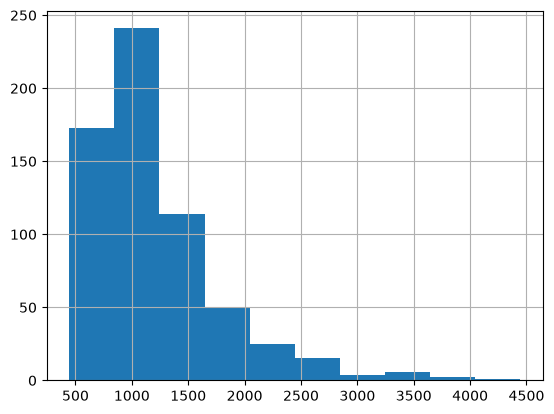

In [155]:
rt_df['rt'].hist()

In [156]:
rt_df['log_rt'] = np.log(rt_df['rt'])
rt_df

,index,participant_id,device,set_size,screen_width,age,gender,ai_use_frequency,ai_detection_experience,target_origin,...,is_practice,no_response,rt,correct,trial_index_global,pic_gender,pic_race,correct_numeric,tp,log_rt
0,470,p_1781092550069_p454,desktop,4.0,1920,21,female,3,3,real,...,False,False,1033.0,True,63.0,female,white,1,True,6.940222
1,475,p_1781092550069_p454,desktop,8.0,1920,21,female,3,3,real,...,False,False,1353.0,True,68.0,female,asian,1,True,7.210080
2,485,p_1781092550069_p454,desktop,8.0,1920,21,female,3,3,real,...,False,False,1157.0,True,78.0,female,asian,1,True,7.053586
3,490,p_1781092550069_p454,desktop,4.0,1920,21,female,3,3,real,...,False,False,858.0,True,83.0,male,asian,1,True,6.754604
4,500,p_1781092550069_p454,desktop,8.0,1920,21,female,3,3,ai,...,False,False,852.0,True,93.0,female,white,1,True,6.747587
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
626,11865,p_1781108603474_wyud,desktop,4.0,1440,18,female,4,3,ai,...,False,False,1366.0,True,138.0,male,white,1,True,7.219642
627,11880,p_1781108603474_wyud,desktop,4.0,1440,18,female,4,3,real,...,False,False,1707.0,True,153.0,female,white,1,True,7.442493
628,11890,p_1781108603474_wyud,desktop,4.0,1440,18,female,4,3,real,...,False,False,775.0,True,163.0,female,black,1,True,6.652863
629,11895,p_1781108603474_wyud,desktop,4.0,1440,18,female,4,3,ai,...,False,False,912.0,True,168.0,female,white,1,True,6.815640


<Axes: >

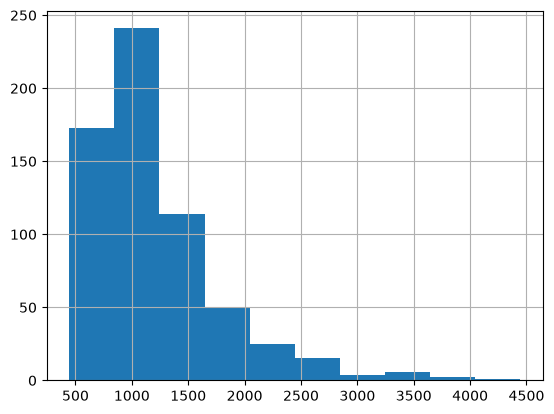

In [157]:
rt_df['rt'].hist()

In [158]:
rt_df.groupby('target_origin')['rt'].mean()

target_origin
ai      1205.924051
real    1222.041270
Name: rt, dtype: float64

In [159]:
model10 = ols("log_rt ~ C(target_origin, Treatment(reference='real'))", data = rt_df).fit(cov_type='cluster', cov_kwds={'groups': rt_df['participant_id']})
model11 = ols("log_rt ~ C(target_origin, Treatment(reference='real')) + set_size + gender + age + ai_use_frequency + ai_detection_experience + C(pic_gender, Treatment(reference='male')) + C(pic_race, Treatment(reference='white'))", data = rt_df).fit(cov_type='cluster', cov_kwds={'groups': rt_df['participant_id']})
model12 = ols("log_rt ~ C(target_origin, Treatment(reference='real'))*set_size + gender + age + ai_use_frequency + ai_detection_experience + C(pic_race, Treatment(reference='white')) + C(pic_gender, Treatment(reference='male'))", data = rt_df).fit(cov_type='cluster', cov_kwds={'groups': rt_df['participant_id']})
model13 = ols("log_rt ~ C(target_origin, Treatment(reference='real'))*C(pic_gender, Treatment(reference='male')) + set_size + gender + age + ai_use_frequency + ai_detection_experience + + C(pic_race, Treatment(reference='white'))", data = rt_df).fit(cov_type='cluster', cov_kwds={'groups': rt_df['participant_id']})
model14 = ols("log_rt ~ C(target_origin, Treatment(reference='real'))*C(pic_race, Treatment(reference='white')) + set_size + gender + age + ai_use_frequency + ai_detection_experience + C(pic_gender, Treatment(reference='male'))", data = rt_df).fit(cov_type='cluster', cov_kwds={'groups': rt_df['participant_id']})

mt.ETable([model10, model11, model12, model13, model14], drop = ['Intercept'])


<maketables.mtable.MTable.__repr__.<locals>.DualOutput at 0x2018ca07620>

In [160]:
marg_man_b = model13.params["C(target_origin, Treatment(reference='real'))[T.ai]"]
marg_man_se = (model13.cov_params().loc["C(target_origin, Treatment(reference='real'))[T.ai]", "C(target_origin, Treatment(reference='real'))[T.ai]"]) ** 0.5

In [161]:
marg_female_b = model13.params["C(target_origin, Treatment(reference='real'))[T.ai]"] + model13.params["C(target_origin, Treatment(reference='real'))[T.ai]:C(pic_gender, Treatment(reference='male'))[T.female]"]
marg_female_se  = (model13.cov_params().loc["C(target_origin, Treatment(reference='real'))[T.ai]", "C(target_origin, Treatment(reference='real'))[T.ai]"] + model13.cov_params().loc["C(target_origin, Treatment(reference='real'))[T.ai]:C(pic_gender, Treatment(reference='male'))[T.female]", "C(target_origin, Treatment(reference='real'))[T.ai]:C(pic_gender, Treatment(reference='male'))[T.female]"] - 2 * model13.cov_params().loc["C(target_origin, Treatment(reference='real'))[T.ai]:C(pic_gender, Treatment(reference='male'))[T.female]","C(target_origin, Treatment(reference='real'))[T.ai]"]) ** 0.5

In [162]:
marg_pic_gender = pd.DataFrame({'AI effect for': ['Male pic', 'Female pic'], 'b': [marg_man_b, marg_female_b], 'se': [marg_man_se, marg_female_se]})
marg_pic_gender['conf_low'] = marg_pic_gender['b']  - norm.ppf(0.975) * marg_pic_gender['se']
marg_pic_gender['conf_high'] = marg_pic_gender['b']  + norm.ppf(0.975) * marg_pic_gender['se']
marg_pic_gender = marg_pic_gender.apply(lambda x: round(x,2)).set_index('AI effect for')

In [163]:
mt.MTable(marg_pic_gender)

<maketables.mtable.MTable.__repr__.<locals>.DualOutput at 0x2018ca07620>

In [164]:
marg_white_b = model14.params["C(target_origin, Treatment(reference='real'))[T.ai]"]
marg_white_se = (model14.cov_params().loc["C(target_origin, Treatment(reference='real'))[T.ai]", "C(target_origin, Treatment(reference='real'))[T.ai]"]) ** 0.5

In [165]:
marg_black_b = model14.params["C(target_origin, Treatment(reference='real'))[T.ai]"] + model14.params["C(target_origin, Treatment(reference='real'))[T.ai]:C(pic_race, Treatment(reference='white'))[T.black]"]
marg_black_se = (model14.cov_params().loc["C(target_origin, Treatment(reference='real'))[T.ai]", "C(target_origin, Treatment(reference='real'))[T.ai]"] + model14.cov_params().loc["C(target_origin, Treatment(reference='real'))[T.ai]:C(pic_race, Treatment(reference='white'))[T.black]", "C(target_origin, Treatment(reference='real'))[T.ai]:C(pic_race, Treatment(reference='white'))[T.black]"] - 2 * model14.cov_params().loc["C(target_origin, Treatment(reference='real'))[T.ai]","C(target_origin, Treatment(reference='real'))[T.ai]:C(pic_race, Treatment(reference='white'))[T.black]"]) ** 0.5
marg_black_b, marg_black_se

(np.float64(0.1638003186121672), np.float64(0.11278542635106321))

In [166]:
marg_asian_b = model14.params["C(target_origin, Treatment(reference='real'))[T.ai]"] + model14.params["C(target_origin, Treatment(reference='real'))[T.ai]:C(pic_race, Treatment(reference='white'))[T.asian]"]
marg_asian_se = (model14.cov_params().loc["C(target_origin, Treatment(reference='real'))[T.ai]", "C(target_origin, Treatment(reference='real'))[T.ai]"] + model14.cov_params().loc["C(target_origin, Treatment(reference='real'))[T.ai]:C(pic_race, Treatment(reference='white'))[T.asian]", "C(target_origin, Treatment(reference='real'))[T.ai]:C(pic_race, Treatment(reference='white'))[T.asian]"] - 2 * model14.cov_params().loc["C(target_origin, Treatment(reference='real'))[T.ai]","C(target_origin, Treatment(reference='real'))[T.ai]:C(pic_race, Treatment(reference='white'))[T.asian]"]) ** 0.5
marg_asian_b, marg_asian_se

(np.float64(0.06360036108561079), np.float64(0.07225143006045202))

In [167]:
marg_race_gender = pd.DataFrame({'AI effect for': ['White', 'Black', 'Asian'], 'b': [marg_white_b, marg_black_b, marg_asian_b], 'se': [marg_white_se, marg_black_se, marg_asian_se]})
marg_race_gender['conf_low'] = marg_race_gender['b']  - norm.ppf(0.975) * marg_race_gender['se']
marg_race_gender['conf_high'] = marg_race_gender['b']  + norm.ppf(0.975) * marg_race_gender['se']
marg_race_gender = marg_race_gender.apply(lambda x: round(x,2)).set_index('AI effect for')

In [168]:
mt.MTable(marg_race_gender)

<maketables.mtable.MTable.__repr__.<locals>.DualOutput at 0x2018ca07620>

---

In [169]:
# исключаем те же невалидные протоколы, что и в основном анализе
excluded_ids = list(accuracy0)
explicit_realism = df[(df['block'] == 'explicit_realism') & (~df['participant_id'].isin(excluded_ids))]
explicit_class   = df[(df['block'] == 'explicit_classification') & (~df['participant_id'].isin(excluded_ids))]

print("Средний рейтинг реалистичности по происхождению (1-7):")
print(explicit_realism.groupby('true_origin')['realism_rating'].mean().round(2))

print("\nТочность явной классификации по происхождению:")
print(explicit_class.groupby('true_origin')['classification_correct'].apply(lambda x: x.astype(float).mean()).round(3))


Средний рейтинг реалистичности по происхождению (1-7):
true_origin
ai      3.63
real    4.30
Name: realism_rating, dtype: float64

Точность явной классификации по происхождению:
true_origin
ai      0.616
real    0.581
Name: classification_correct, dtype: float64
